<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-29-multiple-linear-regression?scriptVersionId=342078335" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [73]:
import numpy as np
import pandas as pd

In [74]:
df = pd.read_csv("/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv")
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


<Axes: >

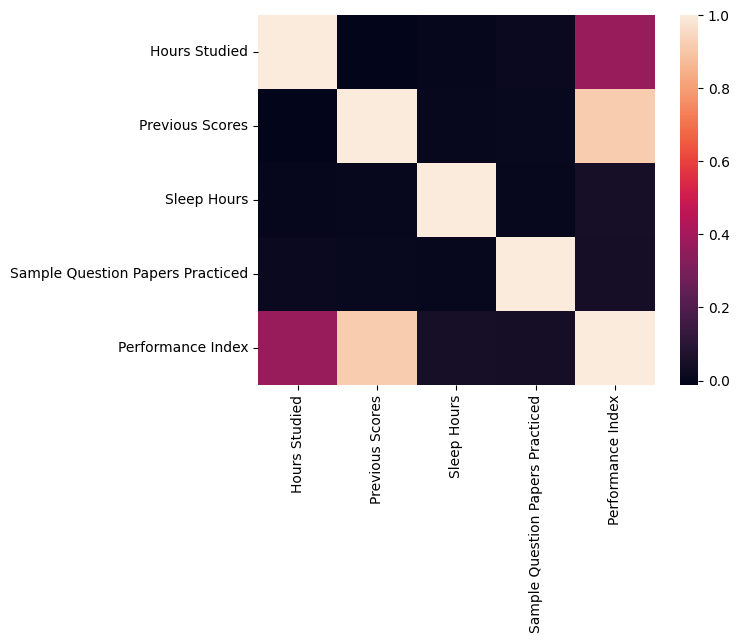

In [75]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True))

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [78]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [79]:
transformer = ColumnTransformer([
    ('encoder', OneHotEncoder(sparse_output=False, drop="first"), [2])
], remainder="passthrough"
)


X_train_trf = transformer.fit_transform(X_train)
X_test_trf = transformer.transform(X_test)

In [80]:
X_train_trf

array([[ 0.,  5., 49.,  5.,  5.],
       [ 1.,  7., 88.,  4.,  9.],
       [ 1.,  3., 94.,  7.,  1.],
       ...,
       [ 0.,  9., 48.,  7.,  6.],
       [ 0.,  1., 47.,  9.,  0.],
       [ 0.,  2., 46.,  6.,  6.]])

In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

model.fit(X_train_trf, y_train)

y_pred = model.predict(X_test_trf)

r2_score(y_test, y_pred)

0.9890550757439104

In [82]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=2)

X_train_new = selector.fit_transform(X_train_trf, y_train)
X_test_new = selector.transform(X_test_trf)

In [83]:
X_train_new

array([[ 5., 49.],
       [ 7., 88.],
       [ 3., 94.],
       ...,
       [ 9., 48.],
       [ 1., 47.],
       [ 2., 46.]])

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model1 = LinearRegression()

model1.fit(X_train_new, y_train)

y_pred1 = model1.predict(X_test_new)

r2_score(y_test, y_pred1)

0.9858714750293637